# Towards grid approximation

The cabinet is considering the purchase of a brand-new drug against a deadly and contagious virus. There are some doubts, however, regarding how effective the new drug is against the virus. You have been tasked with estimating the drug's efficacy rate, i.e. the percentage of patients cured by the drug.

An experiment was quickly set up in which 10 sick patients have been treated with the drug. Once you know how many of them are cured, you can use the binomial distribution with a cured patient being a "success" and the efficacy rate being the "probability of success". While you are waiting for the experiment's results, you decide to prepare the parameter grid.

In [3]:
import pandas as pd
import numpy as np
# Create cured patients array from 1 to 10
num_patients_cured = np.arange(0,11)

# Create efficacy rate array from 0 to 1 by 0.01
efficacy_rate = np.arange(0,1.01,step=0.01)

# Combine the two arrays in one DataFrame
df = pd.DataFrame([(x, y) for x in num_patients_cured for y in efficacy_rate])

# Name the columns
df.columns = ["num_patients_cured", "efficacy_rate"]

# Print df
print(df)

      num_patients_cured  efficacy_rate
0                      0           0.00
1                      0           0.01
2                      0           0.02
3                      0           0.03
4                      0           0.04
...                  ...            ...
1106                  10           0.96
1107                  10           0.97
1108                  10           0.98
1109                  10           0.99
1110                  10           1.00

[1111 rows x 2 columns]


# Grid approximation without prior knowledge

According to the experiment's outcomes, out of 10 sick patients treated with the drug, 9 have been cured. What can you say about the drug's efficacy rate based on such a small sample? Assume you have no prior knowledge whatsoever regarding how good the drug is.

In [5]:
from scipy import stats
# Calculate the prior efficacy rate and the likelihood
df["prior"] = stats.uniform.pdf(df["efficacy_rate"])
df["likelihood"] = stats.binom.pmf(df["num_patients_cured"], 10, df["efficacy_rate"])


# Calculate the posterior efficacy rate and scale it to sum up to one
df["posterior_prob"] = df["prior"]*df["likelihood"]
df["posterior_prob"] = df["posterior_prob"] /df["posterior_prob"].sum()
df.head()

,num_patients_cured,efficacy_rate,prior,likelihood,posterior_prob
0,0,0.00,1.0,1.000000,0.009901
1,0,0.01,1.0,0.904382,0.008954
2,0,0.02,1.0,0.817073,0.008090
3,0,0.03,1.0,0.737424,0.007301
4,0,0.04,1.0,0.664833,0.006583


In [6]:

# Compute the posterior probability of observing 9 cured patients
df_9_of_10_cured = df[df["num_patients_cured"]==9]
df_9_of_10_cured["posterior_prob"] = df_9_of_10_cured["posterior_prob"] /df_9_of_10_cured["posterior_prob"].sum()
df_9_of_10_cured.head()

C:\Users\88016\AppData\Local\Temp/ipykernel_1512/2366380583.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_9_of_10_cured["posterior_prob"] = df_9_of_10_cured["posterior_prob"] /df_9_of_10_cured["posterior_prob"].sum()


,num_patients_cured,efficacy_rate,prior,likelihood,posterior_prob
909,9,0.00,1.0,0.000000e+00,0.000000e+00
910,9,0.01,1.0,9.900000e-18,1.089999e-18
911,9,0.02,1.0,5.017600e-15,5.524422e-16
912,9,0.03,1.0,1.909251e-13,2.102102e-14
913,9,0.04,1.0,2.516582e-12,2.770780e-13


c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


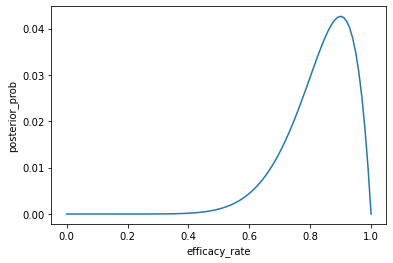

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot the drug's posterior efficacy rate
sns.lineplot(df_9_of_10_cured["efficacy_rate"], df_9_of_10_cured["posterior_prob"])
plt.show()

# Updating posterior belief

Unfortunately, due to a small data sample, this distribution is quite wide, indicating much uncertainty regarding the drug's quality. Luckily, testing of the drug continues, and a group of another 12 sick patients have been treated, 10 of whom were cured. We need to update our posterior distribution with these new data!

This is easy to do with the Bayesian approach. We simply need to run the grid approximation similarly as before, but with a different prior. We can use all our knowledge about the efficacy rate (embodied by the posterior distribution from the previous exercise) as a new prior! Then, we recompute the likelihood for the new data, and get the new posterior!

In [9]:
# Assign old posterior to new prior and calculate likelihood with 12 patients
df["new_prior"] = df["posterior_prob"]
df["new_likelihood"] = stats.binom.pmf(df["num_patients_cured"], 12, df["efficacy_rate"])

# Calculate new posterior and scale it
df["new_posterior_prob"] = df["new_prior"]  * df["new_likelihood"] 
df["new_posterior_prob"] = df["new_posterior_prob"] / df["new_posterior_prob"].sum()

df.head()


,num_patients_cured,efficacy_rate,prior,likelihood,posterior_prob,new_prior,new_likelihood,new_posterior_prob
0,0,0.00,1.0,1.000000,0.009901,0.009901,1.000000,0.050946
1,0,0.01,1.0,0.904382,0.008954,0.008954,0.886385,0.040840
2,0,0.02,1.0,0.817073,0.008090,0.008090,0.784717,0.032665
3,0,0.03,1.0,0.737424,0.007301,0.007301,0.693842,0.026067
4,0,0.04,1.0,0.664833,0.006583,0.006583,0.612710,0.020753


In [10]:
# Compute the posterior probability of observing 10 cured patients
df_10_of_12_cured = df[df["num_patients_cured"]==10]
df_10_of_12_cured["new_posterior_prob"] = df_10_of_12_cured["new_posterior_prob"]/df_10_of_12_cured["new_posterior_prob"].sum()
df_10_of_12_cured.head()

C:\Users\88016\AppData\Local\Temp/ipykernel_1512/1233411330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_10_of_12_cured["new_posterior_prob"] = df_10_of_12_cured["new_posterior_prob"]/df_10_of_12_cured["new_posterior_prob"].sum()


,num_patients_cured,efficacy_rate,prior,likelihood,posterior_prob,new_prior,new_likelihood,new_posterior_prob
1010,10,0.00,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1011,10,0.01,1.0,1.000000e-20,9.900990e-23,9.900990e-23,6.468660e-19,5.207317e-39
1012,10,0.02,1.0,1.024000e-17,1.013861e-19,1.013861e-19,6.490767e-16,5.350517e-33
1013,10,0.03,1.0,5.904900e-16,5.846436e-18,5.846436e-18,3.666907e-14,1.743060e-29
1014,10,0.04,1.0,1.048576e-14,1.038194e-16,1.038194e-16,6.378026e-13,5.383763e-27


c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


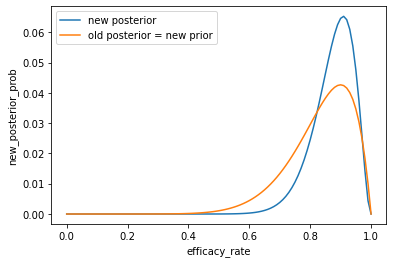

In [11]:
sns.lineplot(df_10_of_12_cured["efficacy_rate"], 
             df_10_of_12_cured["new_posterior_prob"], 
             label="new posterior")
sns.lineplot(df_9_of_10_cured["efficacy_rate"], 
             df_9_of_10_cured["posterior_prob"], 
             label="old posterior = new prior")
plt.show()

- The new posterior is higher and narrower than the old one, which means there is less uncertainty in the estimation.
- Adding the data on the new 12 patients increase our estimate of the drug's effectiveness against the virus.

# The truth of the prior

Choosing the prior distribution is a very important step in Bayesian data analysis. Can you classify the following statements about the prior distribution as either true or false?

<center><img src="images/02.02.png"  style="width: 400px, height: 300px;"/></center>


# Picking the right prior

You continue working on your task to estimate the new drug's efficacy, but with the small data sample you had, you know there is a lot of uncertainty in your estimate. Luckily, a couple of neighboring countries managed to conduct more extensive experiments and have just published their results. You can use them as priors in your analysis!

Having browsed all the publications, you conclude that the reported efficacy rates are mostly between 70% and 90%. A couple of results below 50% were recorded too, but not many.

Which of the following distributions captures this prior information best?

<center><img src="images/02.03.png"  style="width: 400px, height: 300px;"/></center>


- C

# Simulating posterior draws

Since the beta distribution is a conjugate prior for the binomial likelihood, you can simply simulate the posterior!

You know that if the prior is beta distribution, then the posterior is also a beta distribution (because of conjugate prior).
Can you simulate the posterior distribution? Recall that altogether you have data on 22 patients, 19 of whom have been cured

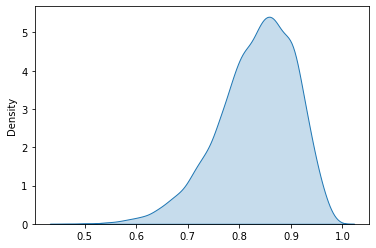

In [13]:
# Define the number of patients treated and cured
num_patients_treated = 22
num_patients_cured = 19
alpha_posterior = 1 + num_patients_cured
beta_posterior = 1 + (num_patients_treated - num_patients_cured)
# Simulate 10000 draws from the posterior distribuition
posterior_draws = np.random.beta(alpha_posterior, beta_posterior, 10000)

# Plot the posterior distribution
sns.kdeplot(posterior_draws, shade=True)
plt.show()

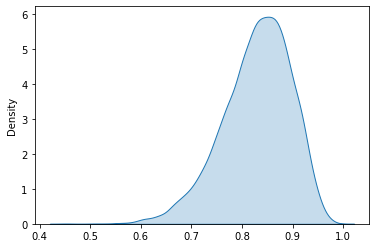

In [14]:
from scipy import stats
# Define the number of patients treated and cured
num_patients_treated = 22
num_patients_cured = 19
alpha_posterior = 1 + num_patients_cured
beta_posterior = 1 + (num_patients_treated - num_patients_cured)
# Simulate 10000 draws from the posterior distribuition
posterior_draws = np.random.beta(num_patients_cured + 5, num_patients_treated - num_patients_cured + 2, 10000)

# Plot the posterior distribution
sns.kdeplot(posterior_draws, shade=True)
plt.show()

# Point estimates

You continue working at your government's Department of Health. You have been tasked with filling the following memo with numbers, before it is sent to the secretary. The number of infected people is 100,000
```
Based on the experiments carried out by ourselves and neighboring countries, should we distribute the drug, we can expect ___ infected people to be cured. There is a 50% probability the number of cured infections will amount to at least ___, and with 90% probability it will not be less than ___.
```


In [15]:
drug_efficacy_posterior_draws = posterior_draws

# Calculate the expected number of people cured
cured_expected = np.mean(drug_efficacy_posterior_draws) * 100_000

# Calculate the minimum number of people cured with 50% probability
min_cured_50_perc = np.median(drug_efficacy_posterior_draws) * 100_000

# Calculate the minimum number of people cured with 90% probability
min_cured_90_perc = np.percentile(drug_efficacy_posterior_draws,10) * 100_000

# Print the filled-in memo
print(f"Based on the experiments carried out by ourselves and neighboring countries, 
      \nshould we distribute the drug, we can expect 
      {int(cured_expected)} infected people to be cured. 
      \nThere is a 50% probability the number of cured infections 
      \nwill amount to at least {int(min_cured_50_perc)}, and with 90% probability 
      \nit will not be less than {int(min_cured_90_perc)}.")



Based on the experiments carried out by ourselves and neighboring countries, 
should we distribute the drug, we can expect 82808 infected people to be cured. 
There is a 50% probability the number of cured infections 
will amount to at least 83516, and with 90% probability 
it will not be less than 73662.


# Highest Posterior Density credible intervals

You know that reporting bare point estimates is not enough. It would be great to provide a measure of uncertainty in the drug's efficacy rate estimate, and you have all the means to do so. You decide to add the following to the memo.
```
The experimental results indicate that with a 90% probability the new drug's efficacy rate is between ___ and ___, and with a 95% probability it is between ___ and ___.
```
You will need to calculate two credible intervals: one of 90% and another of 95% probability.

In [19]:
# Import arviz as az
import arviz as az

# Calculate HPD credible interval of 90%
ci_90 = az.hdi(drug_efficacy_posterior_draws, hdi_prob=.90)

# Calculate HPD credible interval of 95%
ci_95 = az.hdi(drug_efficacy_posterior_draws, hdi_prob=.95)

# Print the memo
print(f"The experimental results indicate that with a 90% probability \
      \nthe new drug's efficacy rate is between {np.round(ci_90[0], 2)} and {np.round(ci_90[1], 2)}, \
      \nand with a 95% probability it is between {np.round(ci_95[0], 2)} and {np.round(ci_95[1], 2)}.")

The experimental results indicate that with a 90% probability       
the new drug's efficacy rate is between 0.72 and 0.94,       
and with a 95% probability it is between 0.7 and 0.95.


# The meaning of credibility

Well done on calculating the Highest Posterior Density credible interval in the last exercise! Here is the 90% interval you have obtained:

(0.72, 0.94)

What is the proper Bayesian interpretation of this credible interval in the context of the drug's efficacy?

There is one correct answer. The other two answers provide two equivalent but differently phrased frequentist interpretations of a confidence interval.

- The probability that the drug's true efficacy rate lies in the interval (0.72, 0.94) is 90%. (True, since parameter is random variable for bayesian inference)
- There is a 90% probability that the interval (0.72, 0.94) contains the drug's true efficacy rate. (False, since parameter is fixed and interval is variable)
- If you had the resources to repeat the experiment many times, in 90% of the cases the interval (0.72, 0.94) would contain the drug's true efficacy rate. (False, since parameter is fixed and interval is variable)